# **Análise dos Índices de Obesidade (IMC) de Fortaleza, em 2024.**

Aluno: Igor Xavier Martins Chaves - 495179 - Ciência de Dados

## **1. Tratamentos dos dados**

**Importando o dataset**

In [1]:
import pandas as pd

data = pd.read_csv(r'C:\Users\igorx\Downloads\vigitel-2006-2024-peso-rake.csv', encoding='latin')

C:\Users\igorx\AppData\Local\Temp\ipykernel_21280\4115571358.py:3: DtypeWarning: Columns (8,10,12,13,14,19,20,21,22,26,27,28,29,30,32,33,34,35,36,38,39,49,51,52,53,57,64,67,68,69,70,71,72,75,76,77,78,79,94,101,104,105,106,107,111,123,127,128,133,134,136,137,138,139,140,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,172,173,174,175,176,177,178,179,180,181,182,183,184,185,188,189,191,192,194,195,196,197,198,199,200,201,202,203,204,205,206,207,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,234,235,236,237,238,239,240,241,242,243,244,245,246,247,249,250,251,252,253,254,257,260,261,263,264,271,272,273,274,275,276,278,279,280,281,282,283,284,285,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,315,316,317,319,320,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,35

In [205]:
data.head()

,ano,cidade,q6,q7,civil,q8a,q8b,q9,q10,q11,...,r705,r706,r707,r801,adultos_fixo,score_upp2024,score_upp_2cat2024,conducao,sono_insuf_curto,insonia
0,2006,curitiba,37,feminino,casado/juntado,primeiro grau (1 a 8),8 ou mais,59.0,entre 1 semana e 1 mês,170.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2006,distrito federal,40,feminino,casado/juntado,segundo grau ou colegial ou técnico (1 a 3),3,90.0,entre 1 semana e 1 mês,146.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2006,goiania,64,feminino,casado/juntado,primeiro grau (1 a 8),5,73.0,6 ou mais meses,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2006,florianopolis,49,masculino,separado/divorciado,superior (1 a 8),3,75.0,entre 1 semana e 1 mês,175.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2006,curitiba,29,feminino,solteiro,superior (1 a 8),7,63.0,entre 1 mês e 3 meses,163.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
data['q11'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 833217 entries, 0 to 833216
Series name: q11
Non-Null Count   Dtype  
--------------   -----  
825572 non-null  float64
dtypes: float64(1)
memory usage: 6.4 MB


**Criação da tabela Obesidade**

In [33]:
obesidade = data[['ano','cidade','q6', 'q7','q9', 'q11']].copy()
obesidade = obesidade.rename(columns={
    'q6': 'idade',
    'q7': 'sexo',
    'q9': 'peso',
    'q11': 'altura'
})

# Converter para numérico 
#obesidade['peso'] = pd.to_numeric(obesidade['peso'], errors='coerce')
#obesidade['altura'] = pd.to_numeric(obesidade['altura'], errors='coerce')
# obesidade['idade'] = pd.to_numeric(obesidade['peso'], errors='coerce')

# Se a altura estiver em centímetros, converter para metros
obesidade['altura'] = obesidade['altura'] / 100

obesidade['IMC'] = obesidade['peso'] / (obesidade['altura'] ** 2)

obesidade.head()

,ano,cidade,idade,sexo,peso,altura,IMC
0,2006,curitiba,37,feminino,59.0,1.70,20.415225
1,2006,distrito federal,40,feminino,90.0,1.46,42.221805
2,2006,goiania,64,feminino,73.0,1.66,26.491508
3,2006,florianopolis,49,masculino,75.0,1.75,24.489796
4,2006,curitiba,29,feminino,63.0,1.63,23.711845


**Tratamento dos dados da tabela Obesidade**

In [34]:
obesidade[['sexo','ano','idade','cidade','peso', 'altura', 'IMC']].isnull().sum()

sexo          0
ano           0
idade         0
cidade        0
peso       4961
altura     7645
IMC       10858
dtype: int64

In [35]:
obesidade.describe()

,ano,idade,peso,altura,IMC
count,833217.000000,833217.000000,828256.000000,825572.000000,822359.000000
mean,2013.607568,47.845088,92.839569,1.997921,29.710522
std,4.969212,17.880644,125.419493,1.428633,37.854894
min,2006.000000,18.000000,29.000000,1.000000,0.380448
25%,2009.000000,33.000000,60.000000,1.590000,22.204082
50%,2013.000000,47.000000,70.000000,1.650000,25.099502
75%,2017.000000,62.000000,80.000000,1.730000,28.532236
max,2024.000000,120.000000,888.000000,8.880000,616.666667


In [36]:
import numpy as np

# Criar uma cópia para tratamento
obesidade_tratado = obesidade.copy()

# Verificar valores incoerentes
peso_invalidos = (
    (obesidade_tratado['peso'] < 30) | 
    (obesidade_tratado['peso'] > 300)
).sum()

altura_invalidos = (
    (obesidade_tratado['altura'] < 1.20) | 
    (obesidade_tratado['altura'] > 2.50)
).sum()

print(f'Pesos inválidos encontrados: {peso_invalidos}')
print(f'Alturas inválidas encontradas: {altura_invalidos}')


# Transformar valores incoerentes em valores ausentes (NaN)
obesidade_tratado.loc[
    (obesidade_tratado['peso'] < 30) | 
    (obesidade_tratado['peso'] > 300),
    'peso'
] = np.nan


obesidade_tratado.loc[
    (obesidade_tratado['altura'] < 1.20) | 
    (obesidade_tratado['altura'] > 2.50),
    'altura'
] = np.nan


# Tratar valores faltantes usando a mediana
obesidade_tratado['peso'] = obesidade_tratado['peso'].fillna(
    obesidade_tratado['peso'].median()
)

obesidade_tratado['altura'] = obesidade_tratado['altura'].fillna(
    obesidade_tratado['altura'].median()
)


# Criar novamente o IMC
obesidade_tratado['IMC'] = (
    obesidade_tratado['peso'] /
    (obesidade_tratado['altura'] ** 2)
)


# Remover IMCs impossíveis
obesidade_tratado.loc[
    (obesidade_tratado['IMC'] < 10) |
    (obesidade_tratado['IMC'] > 80),
    'IMC'
] = np.nan

Pesos inválidos encontrados: 26243
Alturas inválidas encontradas: 47037


In [37]:
obesidade_tratado.describe()

,ano,idade,peso,altura,IMC
count,833217.000000,833217.000000,833217.000000,833217.000000,833203.000000
mean,2013.607568,47.845088,70.271736,1.647878,25.858218
std,4.969212,17.880644,14.751494,0.097429,4.875845
min,2006.000000,18.000000,30.000000,1.200000,10.000000
25%,2009.000000,33.000000,60.000000,1.590000,22.656250
50%,2013.000000,47.000000,69.000000,1.650000,25.344353
75%,2017.000000,62.000000,79.000000,1.700000,28.373702
max,2024.000000,120.000000,300.000000,2.200000,80.000000


In [38]:
obesidade_tratado.head()

,ano,cidade,idade,sexo,peso,altura,IMC
0,2006,curitiba,37,feminino,59.0,1.70,20.415225
1,2006,distrito federal,40,feminino,90.0,1.46,42.221805
2,2006,goiania,64,feminino,73.0,1.66,26.491508
3,2006,florianopolis,49,masculino,75.0,1.75,24.489796
4,2006,curitiba,29,feminino,63.0,1.63,23.711845


## **2. Análise Descritiva dos dados**

### **2.1 Para as Variáveis Numéricas (idade, altura, peso, IMC)**

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
print("\n--- Estatísticas Descritivas (Numéricas) ---")
variaveis_numericas = ['idade', 'altura', 'peso', 'IMC']
print(obesidade_tratado[variaveis_numericas].describe())

# Se quiser a Moda (valor mais comum) de alguma específica:
print(f"\nModa da Idade: {obesidade_tratado['idade'].mode()[0]}")


--- Estatísticas Descritivas (Numéricas) ---
               idade         altura           peso            IMC
count  833217.000000  833217.000000  833217.000000  833203.000000
mean       47.845088       1.647878      70.271736      25.858218
std        17.880644       0.097429      14.751494       4.875845
min        18.000000       1.200000      30.000000      10.000000
25%        33.000000       1.590000      60.000000      22.656250
50%        47.000000       1.650000      69.000000      25.344353
75%        62.000000       1.700000      79.000000      28.373702
max       120.000000       2.200000     300.000000      80.000000

Moda da Idade: 40


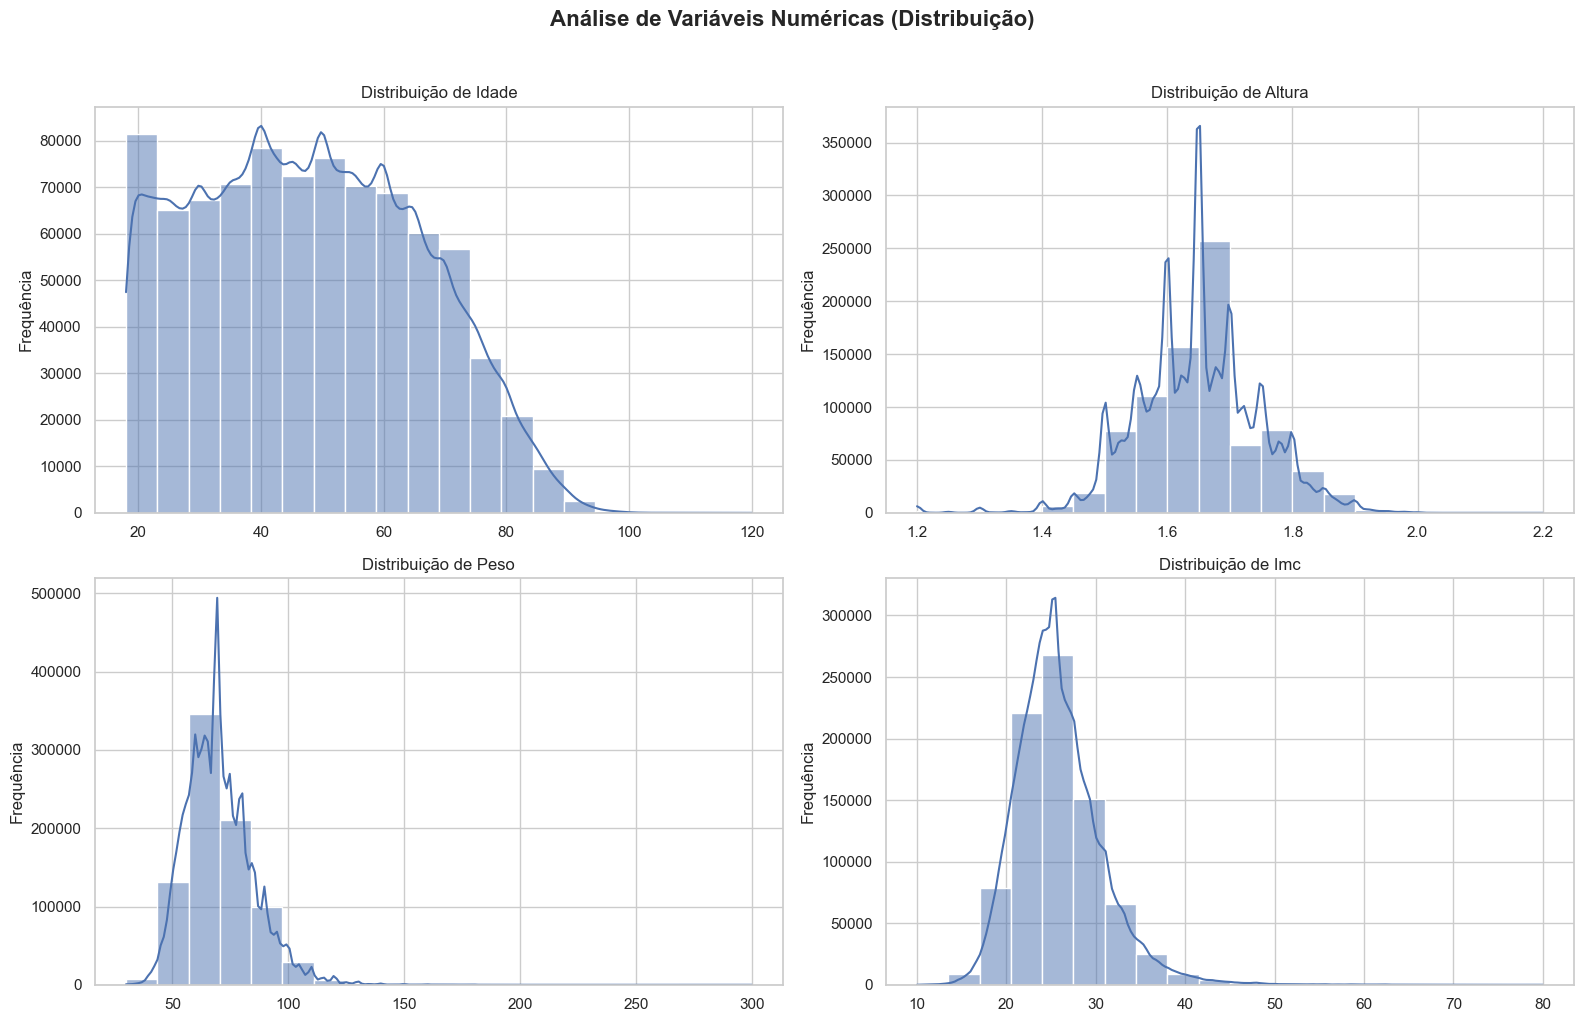

In [61]:
fig_num, axes_num = plt.subplots(2, 2, figsize=(16, 10))
fig_num.suptitle('Análise de Variáveis Numéricas (Distribuição)', fontsize=16, fontweight='bold', y=1.02)

for i, var in enumerate(variaveis_numericas):
    linha = i // 2
    coluna = i % 2
    # Usamos o histplot com a linha de densidade (KDE) ativada
    sns.histplot(data=obesidade_tratado, x=var, kde=True, ax=axes_num[linha, coluna], bins=20)
    axes_num[linha, coluna].set_title(f'Distribuição de {var.capitalize()}', fontsize=12)
    axes_num[linha, coluna].set_xlabel('')
    axes_num[linha, coluna].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

### **2.2 Para as Variáveis Categóricas (cidade, sexo, ano)**

In [45]:
print("\n--- Frequência por Cidade ---")
print(obesidade_tratado['cidade'].value_counts())



--- Frequência por Cidade ---
cidade
belo horizonte      31309
sao paulo           31302
goiania             31257
maceio              31224
natal               31212
recife              31209
porto alegre        31201
curitiba            31196
vitoria             31180
rio de janeiro      31162
fortaleza           31152
cuiaba              31146
teresina            31119
campo grande        31118
aracaju             31106
salvador            31100
distrito federal    31081
belem               31081
sao luis            31070
joao pessoa         31051
florianopolis       30926
porto velho         30739
palmas              30623
manaus              30283
rio branco          29957
boa vista           28806
macapa              28607
Name: count, dtype: int64


In [46]:
print("\n--- Percentual por Sexo ---")
# normalize=True transforma em proporção, multiplicamos por 100 para ver em %
print(obesidade_tratado['sexo'].value_counts(normalize=True) * 100)


--- Percentual por Sexo ---
sexo
feminino     61.886279
masculino    38.113721
Name: proportion, dtype: float64


In [50]:
print("\n--- Média de Peso e IMC por Sexo ---")
print(obesidade_tratado.groupby('sexo')[['peso','altura','IMC']].mean().round(2))

print("\n--- IMC Médio por Cidade e Ano ---")
# Cria uma tabela dinâmica cruzando Cidade nas linhas e Ano nas colunas
tabela_cruzada = obesidade_tratado.pivot_table(index='cidade', columns='ano', values='IMC', aggfunc='mean')
print((tabela_cruzada).round(2))


--- Média de Peso e IMC por Sexo ---
            peso  altura    IMC
sexo                           
feminino   65.56    1.60  25.57
masculino  77.93    1.72  26.33

--- IMC Médio por Cidade e Ano ---
ano                2006   2007   2008   2009   2010   2011   2012   2013  \
cidade                                                                     
aracaju           24.70  24.68  25.15  25.34  25.60  25.44  25.77  25.99   
belem             24.77  24.85  25.03  25.07  25.29  25.52  25.72  25.68   
belo horizonte    24.40  24.76  24.91  25.02  25.06  25.27  25.69  25.54   
boa vista         24.77  24.94  25.13  25.37  25.40  25.63  25.84  25.92   
campo grande      25.13  25.50  25.50  25.73  26.11  26.02  26.47  26.11   
cuiaba            25.02  25.29  25.49  25.51  25.93  26.09  26.03  26.38   
curitiba          25.19  25.23  25.47  25.47  25.80  25.94  26.09  26.12   
distrito federal  24.64  24.76  25.05  25.01  25.24  25.62  25.63  25.89   
florianopolis     24.74  24.80  25.00 

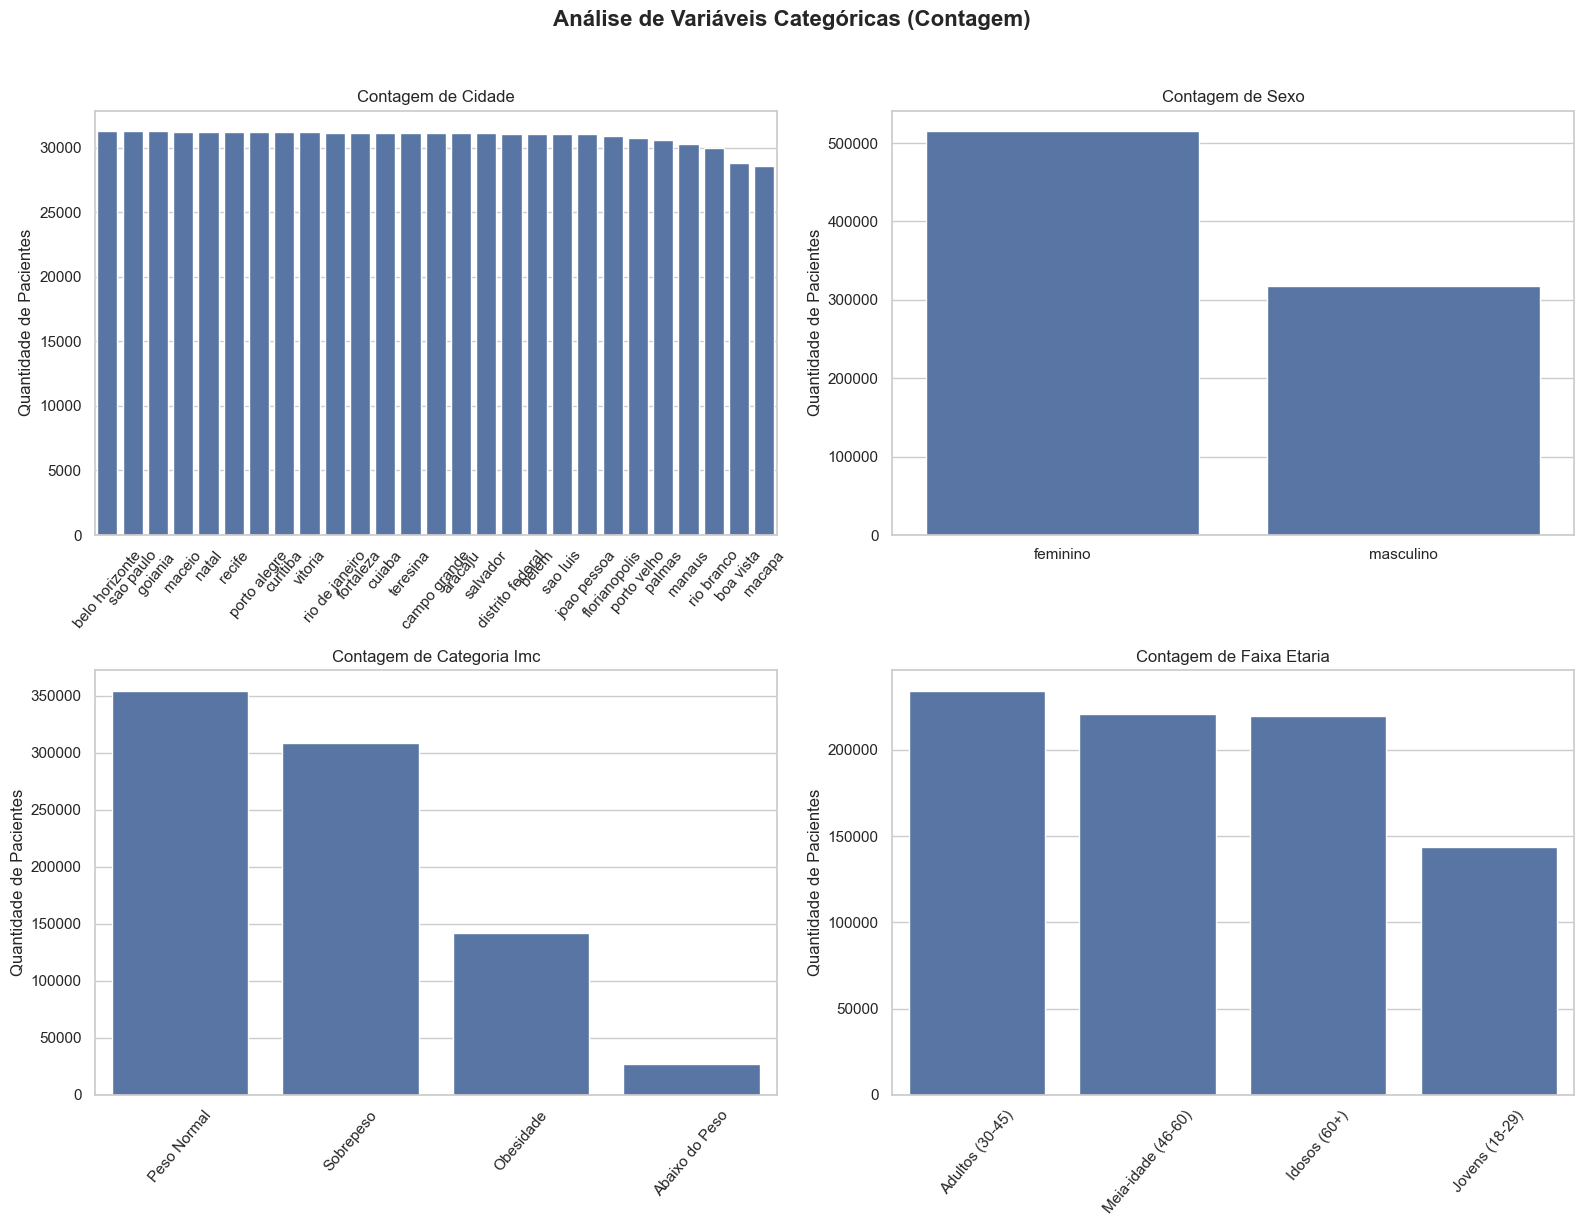

In [70]:
variaveis_categoricas = ['cidade', 'sexo', 'categoria_IMC', 'faixa_etaria']

fig_cat, axes_cat = plt.subplots(2, 2, figsize=(16, 12))
fig_cat.suptitle('Análise de Variáveis Categóricas (Contagem)', fontsize=16, fontweight='bold', y=1.02)

for i, var in enumerate(variaveis_categoricas):
    linha = i // 2
    coluna = i % 2
    
    # Pegamos a ordem dos valores mais frequentes para o gráfico ficar organizado do maior pro menor
    ordem = obesidade_tratado[var].value_counts().index
    
    sns.countplot(data=obesidade_tratado, x=var, order=ordem, ax=axes_cat[linha, coluna])
    axes_cat[linha, coluna].set_title(f'Contagem de {var.replace("_", " ").title()}', fontsize=12)
    axes_cat[linha, coluna].set_xlabel('', fontsize=2)
    axes_cat[linha, coluna].set_ylabel('Quantidade de Pacientes')
    
    # Aplicando a inclinação no eixo X se for cidade, categoria_IMC ou faixa_etaria
    if var in ['cidade', 'categoria_IMC', 'faixa_etaria']:
        axes_cat[linha, coluna].tick_params(axis='x', rotation=50)

plt.tight_layout()
plt.show()

C:\Users\igorx\AppData\Local\Temp\ipykernel_21280\2648127224.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=obesidade_tratado, x='sexo', y='IMC', palette='Set2')
C:\Users\igorx\AppData\Local\Temp\ipykernel_21280\2648127224.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=obesidade_tratado, x='cidade', order=obesidade_tratado['cidade'].value_counts().index, palette='Pastel1')


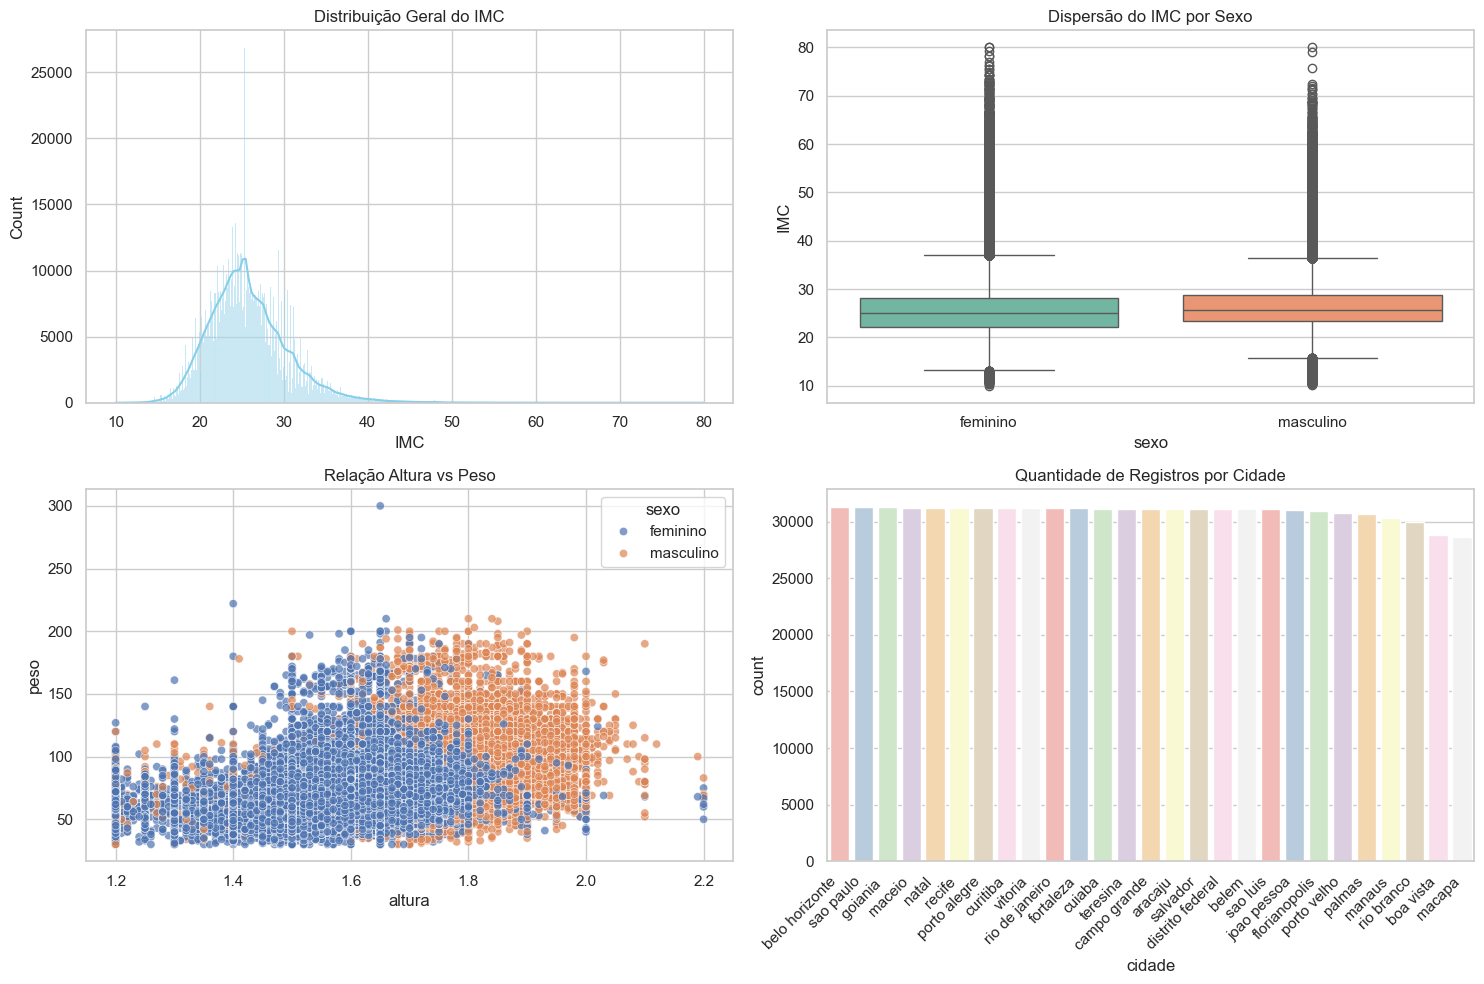

In [ ]:
# Configuração visual do Seaborn
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 10))

# Gráfico 1: Distribuição do IMC (Histograma com linha de densidade)
plt.subplot(2, 2, 1)
sns.histplot(data=obesidade_tratado, x='IMC', kde=True, color='skyblue')
plt.title('Distribuição Geral do IMC')

# Gráfico 2: Comparação de IMC por Sexo (Boxplot - ótimo para ver outliers)
plt.subplot(2, 2, 2)
sns.boxplot(data=obesidade_tratado, x='sexo', y='IMC', palette='Set2')
plt.title('Dispersão do IMC por Sexo')

# Gráfico 3: Relação entre Altura e Peso (Gráfico de Dispersão)
plt.subplot(2, 2, 3)
sns.scatterplot(data=obesidade_tratado, x='altura', y='peso', hue='sexo', alpha=0.7)
plt.title('Relação Altura vs Peso')

# Gráfico 4: Contagem de registros por Cidade (Gráfico de Barras)
plt.subplot(2, 2, 4)
sns.countplot(data=obesidade_tratado, x='cidade', order=obesidade_tratado['cidade'].value_counts().index, palette='Pastel1')
plt.xticks(rotation=45, ha='right')
plt.title('Quantidade de Registros por Cidade')

plt.tight_layout()
plt.show()

In [76]:

# 1.1 Criando as classificações oficiais de IMC (Critério da OMS)
bins_imc = [0, 18.5, 24.9, 29.9, 100]
labels_imc = ['Abaixo do Peso', 'Peso Normal', 'Sobrepeso', 'Obesidade']
obesidade_tratado['categoria_IMC'] = pd.cut(obesidade_tratado['IMC'], bins=bins_imc, labels=labels_imc)

# 1.2 Criando faixas etárias para facilitar a leitura demográfica
bins_idade = [18, 29, 45, 60, 120]
labels_idade = ['Jovens (18-29)', 'Adultos (30-45)', 'Meia-idade (46-60)', 'Idosos (60+)']
obesidade_tratado['faixa_etaria'] = pd.cut(obesidade_tratado['idade'], bins=bins_idade, labels=labels_idade, right=True)

In [77]:
print("\n--- Qual é a prevalência de Obesidade e Sobrepeso por Faixa Etária? ---")
# Criamos uma tabela de contingência com percentuais (cross-tabulation)
tabela_risco = pd.crosstab(obesidade_tratado['faixa_etaria'], obesidade_tratado['categoria_IMC'], normalize='index') * 100
print(tabela_risco.round(2)) # Arredondado para 2 casas decimais

print("\n--- Resumo de Saúde por Cidade (Multivariada) ---")
# Agrupamos por cidade e vemos a média de múltiplos indicadores de uma vez
resumo_cidade = obesidade_tratado.groupby('cidade')[['idade', 'IMC']].mean().round(1)
resumo_cidade['%_Obesidade'] = (obesidade_tratado[obesidade_tratado['categoria_IMC'] == 'Obesidade'].groupby('cidade').size() / obesidade_tratado.groupby('cidade').size()) * 100
print(resumo_cidade)


--- Qual é a prevalência de Obesidade e Sobrepeso por Faixa Etária? ---
categoria_IMC       Abaixo do Peso  Peso Normal  Sobrepeso  Obesidade
faixa_etaria                                                         
Jovens (18-29)                6.12        57.32      27.26       9.29
Adultos (30-45)               2.48        42.68      37.25      17.59
Meia-idade (46-60)            1.88        36.88      40.38      20.86
Idosos (60+)                  3.15        36.97      41.23      18.65

--- Resumo de Saúde por Cidade (Multivariada) ---
                  idade   IMC  %_Obesidade
cidade                                    
aracaju            47.0  25.8    17.028869
belem              46.6  25.8    16.788392
belo horizonte     49.3  25.6    15.133029
boa vista          42.4  25.9    17.597028
campo grande       50.8  26.3    19.567453
cuiaba             47.7  26.2    19.488859
curitiba           51.1  26.1    17.710604
distrito federal   48.6  25.7    15.314823
florianopolis      51.7  2

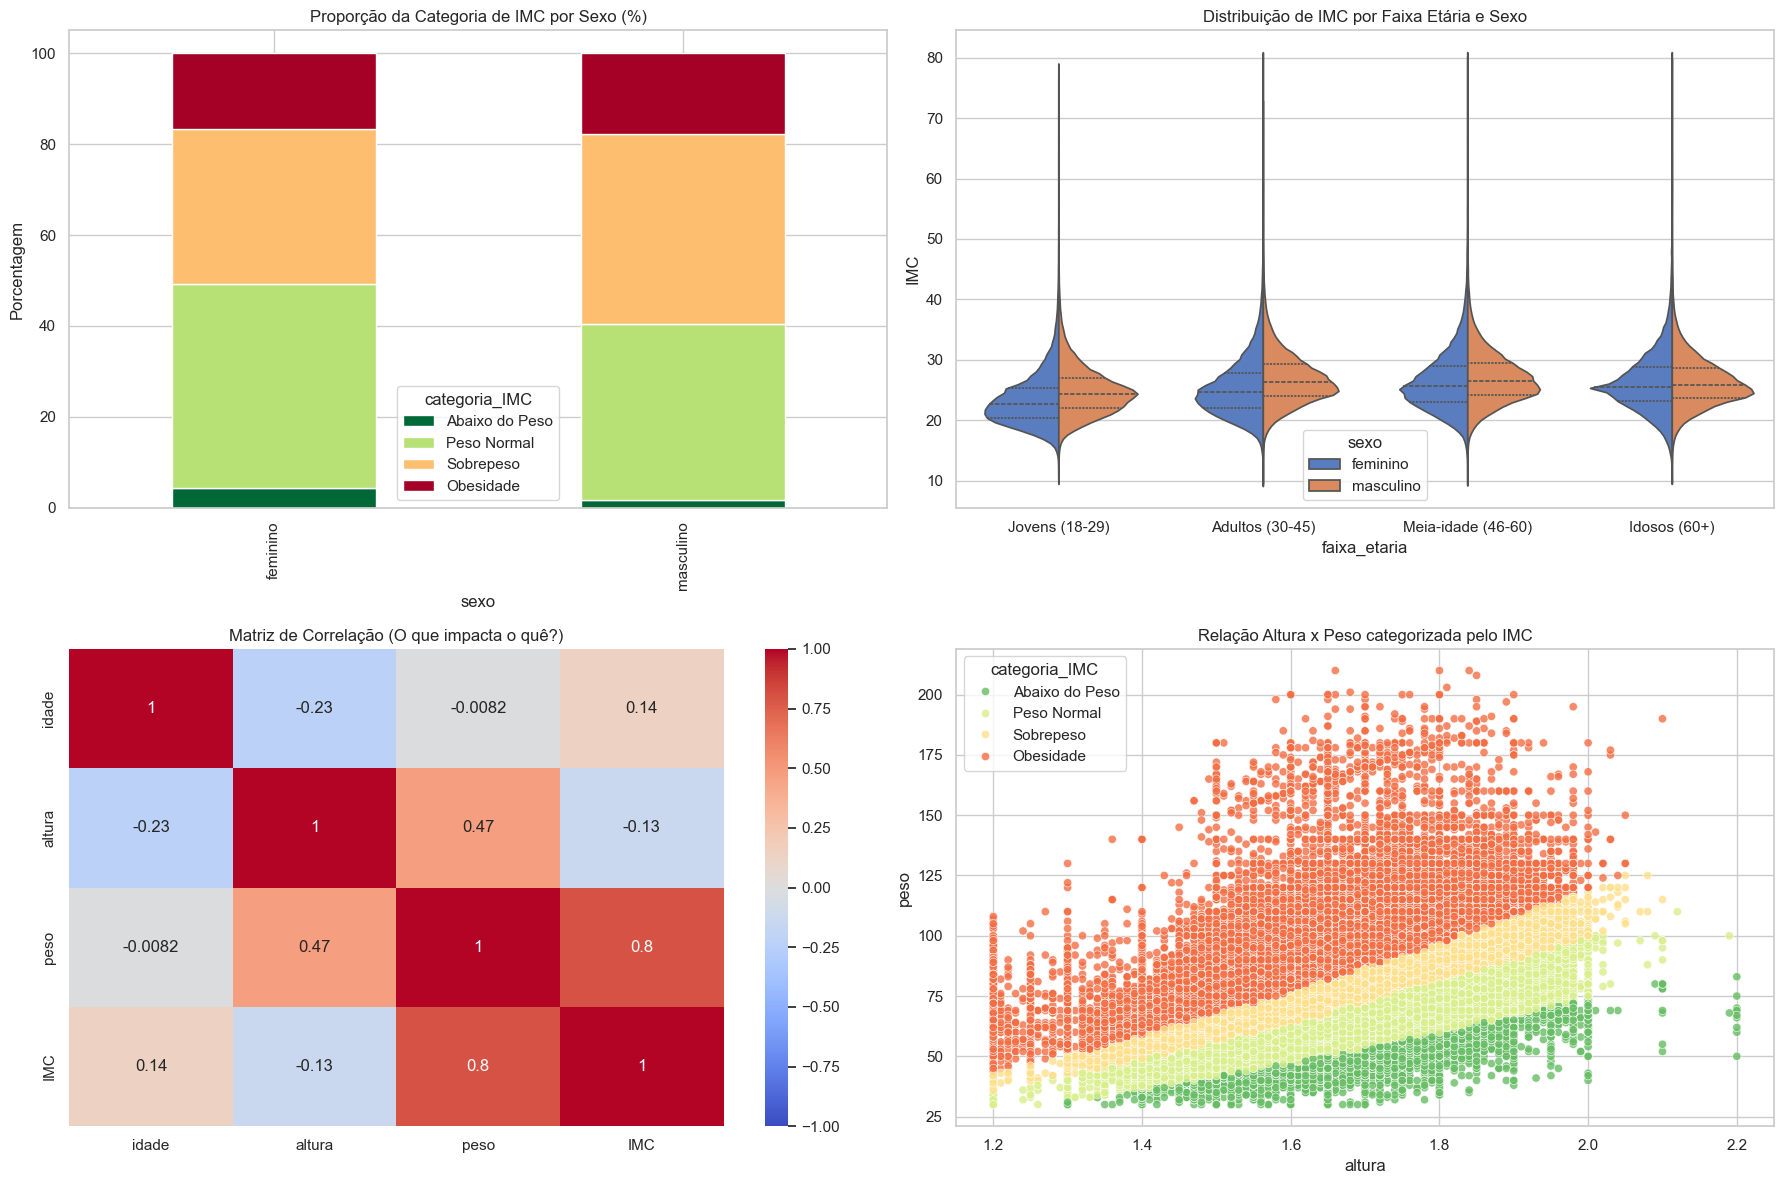

In [78]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Gráfico 1: Proporção de Categorias de IMC por Sexo (Gráfico de Barras Empilhadas)
# Mostra claramente se a distribuição de saúde difere entre homens e mulheres
tabela_sexo_imc = pd.crosstab(obesidade_tratado['sexo'], obesidade_tratado['categoria_IMC'], normalize='index') * 100
tabela_sexo_imc.plot(kind='bar', stacked=True, ax=axes[0, 0], colormap='RdYlGn_r')
axes[0, 0].set_title('Proporção da Categoria de IMC por Sexo (%)')
axes[0, 0].set_ylabel('Porcentagem')

# Gráfico 2: Violin Plot (Idade x IMC com divisão por Sexo)
# mostra a densidade e o formato exato da distribuição
sns.violinplot(data=obesidade_tratado, x='faixa_etaria', y='IMC', hue='sexo', split=True, inner="quart", palette='muted', ax=axes[0, 1])
axes[0, 1].set_title('Distribuição de IMC por Faixa Etária e Sexo')

# Gráfico 3: Matriz de Correlação (Heatmap)
# Revela a força da ligação matemática entre as variáveis numéricas
variaveis_numericas = obesidade_tratado[['idade', 'altura', 'peso', 'IMC']]
matriz_correlacao = variaveis_numericas.corr()
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1, 0])
axes[1, 0].set_title('Matriz de Correlação (O que impacta o quê?)')

# Gráfico 4: Dispersão com 3 Variáveis (Altura vs Peso, colorido pelo IMC)
# Mostra a fronteira visual de onde começa o sobrepeso e a obesidade
sns.scatterplot(data=obesidade_tratado, x='altura', y='peso', hue='categoria_IMC', palette='RdYlGn_r', alpha=0.8, ax=axes[1, 1])
axes[1, 1].set_title('Relação Altura x Peso categorizada pelo IMC')

plt.tight_layout()
plt.show()

In [84]:
obesidade_tratado.to_csv(r'C:\Users\igorx\OneDrive\Desktop\Projetos\Python\analise-inferencial-obesidade\data\obesidade_tratado.csv')

## **3. Teste de hipótese**

**Afirmação inicial: *A prevalência de obesidade em adultos residentes em Fortaleza no ano de 2024, utilizando o Índice de Massa Corporal (IMC) como indicador, difere da prevalência histórica observada em 2023 nos dados do Vigitel.*** 

**Hipótese:**

<div align="center">

$H_0: p = p_0$

$H_1: p \neq p_0$

onde:

- $p$ = prevalência de obesidade em Fortaleza em 2024;
- $p_0$ = prevalência de obesidade em Fortaleza em 2023.

### **3.1 Criando uma variável categórica de obesidade e escolhendo o objeto de interesse (dados de Fortaleza, em 2024)**

<div align="center">

$IMC \geq 30 \rarr$  Obeso

In [86]:
obesidade_2024 = obesidade_tratado[
    (obesidade_tratado['cidade'] == 'fortaleza') & 
    (obesidade_tratado['ano'] == 2024)
].copy()

obesidade_2024['obeso'] = (
    obesidade_2024['IMC'] >= 30
).astype(int)

obesidade_2024.head()

,ano,cidade,idade,sexo,peso,altura,IMC,categoria_IMC,faixa_etaria,obeso
806182,2024,fortaleza,42,masculino,69.0,1.65,25.344353,Sobrepeso,Adultos (30-45),0
806262,2024,fortaleza,39,masculino,75.0,1.87,21.447568,Peso Normal,Adultos (30-45),0
806263,2024,fortaleza,44,masculino,92.0,1.65,33.792470,Obesidade,Adultos (30-45),1
806265,2024,fortaleza,42,masculino,63.0,1.65,23.140496,Peso Normal,Adultos (30-45),0
806322,2024,fortaleza,18,masculino,101.0,1.85,29.510592,Sobrepeso,NaN,0


In [87]:
print(f'Tamanho: {len(obesidade_2024)}')

Tamanho: 1000


### **3.2 Cálculo do tamanho mínimo de amostra**